# Delta-rule value learning (1000 trials)

Simulate 1000 trials where rewards are sampled from a Bernoulli process with $p(\text{reward})=0.7$.
The learner updates value using a simple delta rule with $\alpha=0.4$, initialized at $V_0=0.5$.
A pandas DataFrame stores the value before reward and the observed reward on each trial.

In [1]:
import numpy as np
import pandas as pd

# Parameters
n_trials = 1000
p_reward = 0.7
alpha = .10
value = 0  # initial value
noise_std = .30  # standard deviation of noise added to the value estimate

# Reproducible random generator
rng = np.random.default_rng(42)

records = []

for trial in range(1, n_trials + 1):
    value_before_reward = value + rng.normal(0, noise_std)  # add noise to the value estimate
    reward = rng.binomial(1, p_reward)

    records.append({
        "trial": trial,
        "value_before_reward": value_before_reward,
        "reward": reward
    })

    # Delta-learning update
    value = value + alpha * (reward - value)

df = pd.DataFrame(records)
df

,trial,value_before_reward,reward
0,1,0.091415,1
1,2,0.325135,1
2,3,-0.395311,0
3,4,0.209352,0
4,5,0.148860,1
...,...,...,...
995,996,0.916817,1
996,997,0.767576,1
997,998,1.053708,1
998,999,0.741261,1


/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-tdtrxvvo because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


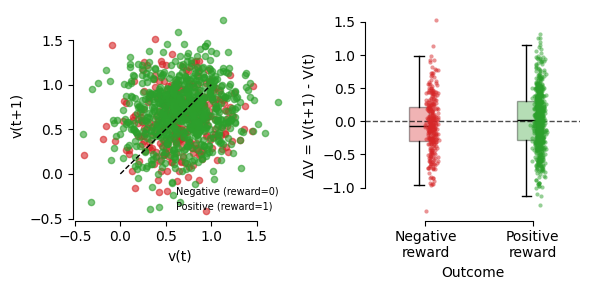

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Build transition dataset: v(t) is value_before_reward at trial t,
# v(t+1) is value_before_reward at trial t+1.
df_transitions = df.copy()
df_transitions["v_t"] = df_transitions["value_before_reward"]
df_transitions["v_t1"] = df_transitions["value_before_reward"].shift(-1)
df_transitions = df_transitions.dropna(subset=["v_t1"]).copy()
df_transitions["delta_v"] = df_transitions["v_t1"] - df_transitions["v_t"]
df_transitions["reward_label"] = df_transitions["reward"].map({0: "Negative reward", 1: "Positive reward"})

fig, axes = plt.subplots(1, 2, figsize=(6, 3), gridspec_kw={"width_ratios": [1, 1]})
ax1, ax2 = axes

neg = df_transitions[df_transitions["reward"] == 0]
pos = df_transitions[df_transitions["reward"] == 1]

# Left subplot: v(t) vs v(t+1), conditioned on outcome
ax1.scatter(neg["v_t"], neg["v_t1"], s=20, alpha=0.6, color="tab:red", label="Negative (reward=0)")
ax1.scatter(pos["v_t"], pos["v_t1"], s=20, alpha=0.6, color="tab:green", label="Positive (reward=1)")
ax1.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
'''ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_aspect("equal", adjustable="box")'''
ax1.set_xlabel("v(t)")
ax1.set_ylabel("v(t+1)")
ax1.legend(frameon=False, fontsize=7)

# Right subplot: delta V by reward (narrow boxplot + slightly offset stripplot)
order = ["Negative reward", "Positive reward"]
palette = {"Negative reward": "tab:red", "Positive reward": "tab:green"}

box_positions = np.array([0.0, 1.0]) - 0.06
strip_positions = np.array([0.0, 1.0]) + 0.06
group_data = [
    df_transitions.loc[df_transitions["reward_label"] == label, "delta_v"].values
    for label in order
]

bp = ax2.boxplot(
    group_data,
    positions=box_positions,
    widths=0.18,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1},
    whiskerprops={"linewidth": 1},
    capprops={"linewidth": 1},
    boxprops={"linewidth": 1},
)
for patch, label in zip(bp["boxes"], order):
    patch.set_facecolor(palette[label])
    patch.set_alpha(0.35)

for i, label in enumerate(order):
    y_vals = df_transitions.loc[df_transitions["reward_label"] == label, "delta_v"].values
    x_vals = np.random.normal(strip_positions[i], 0.025, size=len(y_vals))
    ax2.scatter(
        x_vals, y_vals, s=9, alpha=0.5, color=palette[label],
        linewidth=0, zorder=10
    )

ax2.axhline(0, linestyle="--", color="black", linewidth=1, alpha=0.7)
ax2.set_xlabel("Outcome")
ax2.set_ylabel("ΔV = V(t+1) - V(t)")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Negative\nreward", "Positive\nreward"])

sns.despine(ax=ax1, trim=True)
sns.despine(ax=ax2, trim=True)
plt.tight_layout()
plt.show()

In [3]:
import os
import sys
import pandas as pd

# Import helper functions used in the population decoding notebook.
try:
    from helpers import fit_mixed_glm, stat_tests_mixed_glm, add_hypothesis
except ImportError:
    helper_dir = os.path.join("notebooks", "population_decoding", "neural_value")
    if helper_dir not in sys.path:
        sys.path.append(helper_dir)
    from helpers import fit_mixed_glm, stat_tests_mixed_glm, add_hypothesis

# Build a session-like dataframe matching the expected columns in make_session_summary().
subdf = df_transitions.rename(columns={
    "v_t1": "V_neural_p1",
    "v_t": "V_neural",
    "reward": "feedback"
}).copy()
subdf["type"] = "within"

# get hypothesis
data_temp = pd.DataFrame({
    "A": subdf[subdf["type"] == "within"]["V_neural_p1"].values,
    "B": subdf[subdf["type"] == "within"]["V_neural"].values,
    "C": subdf[subdf["type"] == "within"]["feedback"].values,
})

results_mixed = fit_mixed_glm(data_temp)
test_results = stat_tests_mixed_glm(results_mixed)
hypothesis = add_hypothesis(test_results)

print("Hypothesis:", hypothesis)
pd.DataFrame([test_results]).T.rename(columns={0: "value"})

Hypothesis: Other


,value
slope_c0,0.096485
slope_c1,0.104496
intercept_c0,0.548392
intercept_c1,0.630019
b1_c0_pvalue,0.107379
b1_c0_significant,False
b1_c1_pvalue,0.004525
b1_c1_significant,True
b1_c0_ci,"(-0.021003501558633522, 0.21397302811373015)"
b1_c0_within_bounds,False


In [4]:
from scipy import stats

# Build a group-like table matching your analysis naming.
group = df_transitions.rename(columns={
    "reward": "feedback",
    "delta_v": "dV_neural",
}).copy()
group["type"] = "within"
type_ = "within"

# compute significance of modulation between positive and negative feedback for this session, subregion, type
dVs_pos = group[(group["feedback"] == 1) & (group["type"] == type_)]["dV_neural"].values
dVs_neg = group[(group["feedback"] == 0) & (group["type"] == type_)]["dV_neural"].values
U, p_value = stats.mannwhitneyu(dVs_pos, dVs_neg, alternative="two-sided")
if_signif = p_value < 0.05

print(f"U statistic: {U:.3f}")
print(f"p-value: {p_value:.6g}")
print(f"Significant modulation (p < 0.05): {if_signif}")

U statistic: 117178.000
p-value: 0.00692022
Significant modulation (p < 0.05): True
